In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [6]:
df = pd.read_csv('processed_cleveland.csv', na_values = ['?'])
df = df.dropna()
df['y'] = 1 * (df['num'] > 0)
df['sex'] = df['sex'].replace({1: 'male', 0: 'female'})
df['cp'] = df['cp'].replace({1: 'typical', 2:'atypical', 3: 'non-anginal', 4: 'asymptomatic'})
df['fbs'] = df['fbs'].replace({1: 'high', 0: 'typical'})
df['restecg'] = df['restecg'].replace({0: 'normal', 1:'ST-T wave abnormality', 2: 'left ventricular hypertrophy'})
df['exang'] = df['exang'].replace({0: 'no', 1: 'yes'})
df['slope'] = df['slope'].replace({1:'upsloping', 2:'flat', 3:'downsloping'})
df['thal'] = df['thal'].replace({3: 'normal', 6: 'fixed defect', 7:'reversible defect'})
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y
0,63,male,typical,145,233,high,left ventricular hypertrophy,150,no,2.3,downsloping,0.0,fixed defect,0,0
1,67,male,asymptomatic,160,286,typical,left ventricular hypertrophy,108,yes,1.5,flat,3.0,normal,2,1
2,67,male,asymptomatic,120,229,typical,left ventricular hypertrophy,129,yes,2.6,flat,2.0,reversible defect,1,1
3,37,male,non-anginal,130,250,typical,normal,187,no,3.5,downsloping,0.0,normal,0,0
4,41,female,atypical,130,204,typical,left ventricular hypertrophy,172,no,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,female,asymptomatic,140,241,typical,normal,123,yes,0.2,flat,0.0,reversible defect,1,1
298,45,male,typical,110,264,typical,normal,132,no,1.2,flat,0.0,reversible defect,1,1
299,68,male,asymptomatic,144,193,high,normal,141,no,3.4,flat,2.0,reversible defect,2,1
300,57,male,asymptomatic,130,131,typical,normal,115,yes,1.2,flat,1.0,reversible defect,3,1


In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y
0,63,male,typical,145,233,high,left ventricular hypertrophy,150,no,2.3,downsloping,0.0,fixed defect,0,0
1,67,male,asymptomatic,160,286,typical,left ventricular hypertrophy,108,yes,1.5,flat,3.0,normal,2,1
2,67,male,asymptomatic,120,229,typical,left ventricular hypertrophy,129,yes,2.6,flat,2.0,reversible defect,1,1
3,37,male,non-anginal,130,250,typical,normal,187,no,3.5,downsloping,0.0,normal,0,0
4,41,female,atypical,130,204,typical,left ventricular hypertrophy,172,no,1.4,upsloping,0.0,normal,0,0


In [8]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size = 0.20, random_state = 403)

In [9]:
df_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y
22,58,male,atypical,120,284,typical,left ventricular hypertrophy,160,no,1.8,flat,0.0,normal,1,1
262,60,female,typical,150,240,typical,normal,171,no,0.9,upsloping,0.0,normal,0,0
200,50,female,asymptomatic,110,254,typical,left ventricular hypertrophy,159,no,0.0,upsloping,0.0,normal,0,0
246,58,male,asymptomatic,100,234,typical,normal,156,no,0.1,upsloping,1.0,reversible defect,2,1
100,45,male,asymptomatic,115,260,typical,left ventricular hypertrophy,185,no,0.0,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,52,male,typical,152,298,high,normal,178,no,1.2,flat,0.0,reversible defect,0,0
52,44,male,asymptomatic,112,290,typical,left ventricular hypertrophy,153,no,0.0,upsloping,1.0,normal,2,1
207,50,male,asymptomatic,144,200,typical,left ventricular hypertrophy,126,yes,0.9,flat,0.0,reversible defect,3,1
120,48,male,asymptomatic,130,256,high,left ventricular hypertrophy,150,yes,0.0,upsloping,2.0,reversible defect,3,1


In [10]:
df_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y
188,54,male,atypical,192,283,typical,left ventricular hypertrophy,195,no,0.0,upsloping,1.0,reversible defect,1,1
124,65,male,typical,138,282,high,left ventricular hypertrophy,174,no,1.4,flat,1.0,normal,1,1
35,42,male,asymptomatic,140,226,typical,normal,178,no,0.0,upsloping,0.0,normal,0,0
151,42,female,asymptomatic,102,265,typical,left ventricular hypertrophy,122,no,0.6,flat,0.0,normal,0,0
14,52,male,non-anginal,172,199,high,normal,162,no,0.5,upsloping,0.0,reversible defect,0,0
62,58,male,asymptomatic,128,216,typical,left ventricular hypertrophy,131,yes,2.2,flat,3.0,reversible defect,1,1
143,64,male,non-anginal,125,309,typical,normal,131,yes,1.8,flat,0.0,reversible defect,1,1
284,61,male,asymptomatic,148,203,typical,normal,161,no,0.0,upsloping,1.0,reversible defect,2,1
198,50,female,atypical,120,244,typical,normal,162,no,1.1,upsloping,0.0,normal,0,0
127,54,male,asymptomatic,110,239,typical,normal,126,yes,2.8,flat,1.0,reversible defect,3,1


## Using a Logistic Regression Model

In [11]:
model_age = smf.logit("y ~ age", data = df_train).fit()
print(model_age.summary())

Optimization terminated successfully.
         Current function value: 0.671837
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            1
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                 0.02713
Time:                        23:16:49   Log-Likelihood:                -159.23
converged:                       True   LL-Null:                       -163.67
Covariance Type:            nonrobust   LLR p-value:                  0.002882
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.4903      0.820     -3.038      0.002      -4.097      -0.883
age            0.0429      0.

In [12]:
import numpy as np

In [13]:
model_age.params[0]

/var/folders/zx/xb_pyd9j7xb14lw03l9bl2x00000gn/T/ipykernel_41224/1111030024.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_age.params[0]


np.float64(-2.490307718653418)

In [14]:
model_age.params["Intercept"]

np.float64(-2.490307718653418)

In [15]:
intercept = model_age.params["Intercept"]
odds_0 = np.exp(intercept)
odds_0


np.float64(0.08288445755690489)

In [16]:
prob_35 = model_age.predict({"age": 35})
prob_35

0    0.271375
dtype: float64

In [17]:
p_threshold = 0.7
log_odds = np.log(p_threshold / (1 - p_threshold))
age_threshold = (log_odds - (model_age.params[0])) / model_age.params[1]
age_threshold

/var/folders/zx/xb_pyd9j7xb14lw03l9bl2x00000gn/T/ipykernel_41224/3301525032.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age_threshold = (log_odds - (model_age.params[0])) / model_age.params[1]


np.float64(77.74007013843622)

In [18]:
age_coef = model_age.params["age"]
odds_ratio = np.exp(age_coef)
odds_ratio

np.float64(1.0438678344901438)

In [19]:
model_age.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            1
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                 0.02713
Time:                        23:16:49   Log-Likelihood:                -159.23
converged:                       True   LL-Null:                       -163.67
Covariance Type:            nonrobust   LLR p-value:                  0.002882
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.4903      0.820     -3.038      0.002      -4.097      -0.883
age            0.0429      0.015      2.909      0.004       0.014       0.072
==============================================================================
"""

In [20]:
p_value = model_age.pvalues["age"]
p_value

np.float64(0.003622347842170523)

## Evaluating Model Assumptions

In [21]:
pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.


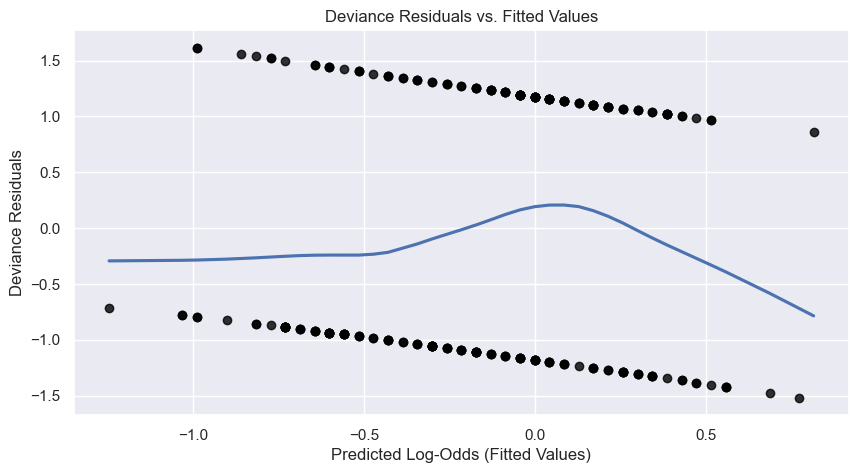

In [22]:
plt.figure(figsize=(10,5))
sns.regplot(x=model_age.fittedvalues, y=model_age.resid_dev,
            color="black",
            line_kws={"color":"b"}, lowess=True)

plt.title("Deviance Residuals vs. Fitted Values")
plt.xlabel("Predicted Log-Odds (Fitted Values)")
plt.ylabel("Deviance Residuals")
plt.show()

## Fitting a more complex model

In [23]:
complex_model = smf.logit(
    "y ~ age + sex + restecg + thalach + exang + oldpeak + slope + ca + thal",
    data = df_train
).fit()

print(complex_model.summary())

Optimization terminated successfully.
         Current function value: 0.320657
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      224
Method:                           MLE   Df Model:                           12
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.5357
Time:                        23:16:50   Log-Likelihood:                -75.996
converged:                       True   LL-Null:                       -163.67
Covariance Type:            nonrobust   LLR p-value:                 3.852e-31
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   6.1391

In [24]:
from sklearn.metrics import roc_auc_score

In [25]:
roc_auc_score(df_train["y"], complex_model.predict(df_train))

0.9333571939871151

## Build a classifier

In [26]:
pred = complex_model.predict(df_train)

df_train["y_pred"] = (pred >= 0.75).astype(int)
df_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y,y_pred
22,58,male,atypical,120,284,typical,left ventricular hypertrophy,160,no,1.8,flat,0.0,normal,1,1,0
262,60,female,typical,150,240,typical,normal,171,no,0.9,upsloping,0.0,normal,0,0,0
200,50,female,asymptomatic,110,254,typical,left ventricular hypertrophy,159,no,0.0,upsloping,0.0,normal,0,0,0
246,58,male,asymptomatic,100,234,typical,normal,156,no,0.1,upsloping,1.0,reversible defect,2,1,0
100,45,male,asymptomatic,115,260,typical,left ventricular hypertrophy,185,no,0.0,upsloping,0.0,normal,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,52,male,typical,152,298,high,normal,178,no,1.2,flat,0.0,reversible defect,0,0,0
52,44,male,asymptomatic,112,290,typical,left ventricular hypertrophy,153,no,0.0,upsloping,1.0,normal,2,1,0
207,50,male,asymptomatic,144,200,typical,left ventricular hypertrophy,126,yes,0.9,flat,0.0,reversible defect,3,1,1
120,48,male,asymptomatic,130,256,high,left ventricular hypertrophy,150,yes,0.0,upsloping,2.0,reversible defect,3,1,1


In [27]:
from sklearn.metrics import confusion_matrix

In [28]:
matrix = confusion_matrix(df_train["y"], df_train["y_pred"])
print(matrix)

[[121   6]
 [ 33  77]]


In [29]:
accuracy = (77 + 121)/ (121 + 6 + 33 + 77)
accuracy

0.8354430379746836

## Test data

In [30]:
complex_model = smf.logit(
    "y ~ age + sex + restecg + thalach + exang + oldpeak + slope + ca + thal",
    data = df_train
).fit()

print(complex_model.summary())

Optimization terminated successfully.
         Current function value: 0.320657
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      224
Method:                           MLE   Df Model:                           12
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.5357
Time:                        23:16:50   Log-Likelihood:                -75.996
converged:                       True   LL-Null:                       -163.67
Covariance Type:            nonrobust   LLR p-value:                 3.852e-31
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   6.1391

In [31]:
prediction = complex_model.predict(df_test)
prediction

prediction.head(10)

188    0.638764
124    0.322066
35     0.033091
151    0.250493
14     0.317784
62     0.999504
143    0.789852
284    0.632536
198    0.017216
127    0.977812
dtype: float64

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
prediction_class = (prediction >= 0.75).astype(int)
prediction_class.head(10)

188    0
124    0
35     0
151    0
14     0
62     1
143    1
284    0
198    0
127    1
dtype: int64

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy = accuracy_score(df_test["y"], prediction_class)
accuracy

0.8

In [36]:
df['y'].value_counts(normalize=True).rename('proportion')

y
0    0.538721
1    0.461279
Name: proportion, dtype: float64

## Outcome + Feature EDA

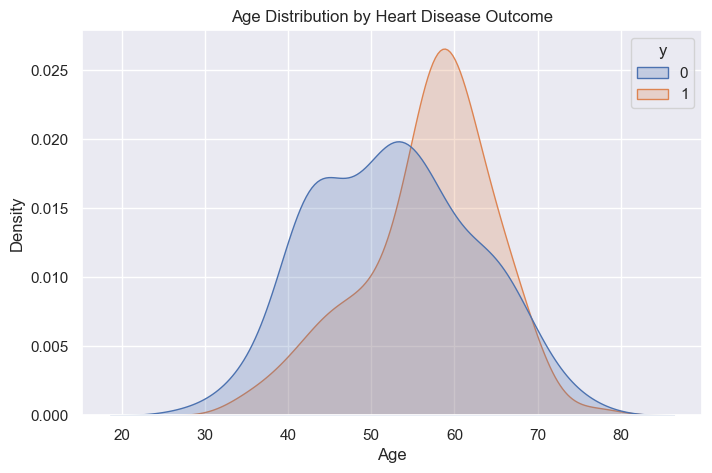

In [37]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='age', hue='y', fill=True)
plt.title('Age Distribution by Heart Disease Outcome')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

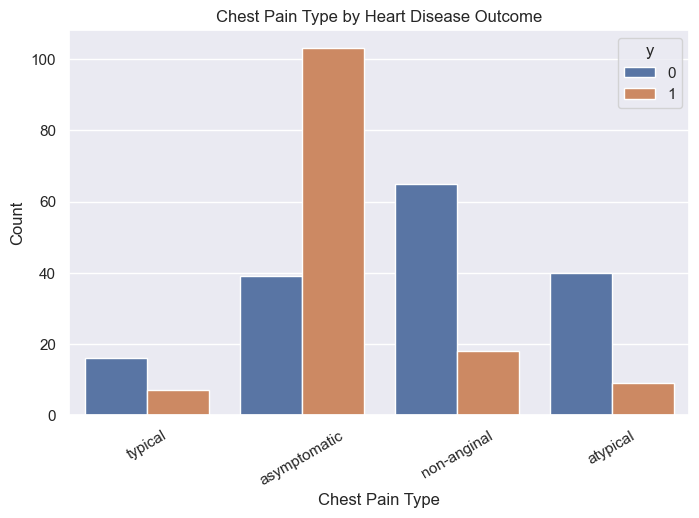

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cp', hue='y')
plt.title('Chest Pain Type by Heart Disease Outcome')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

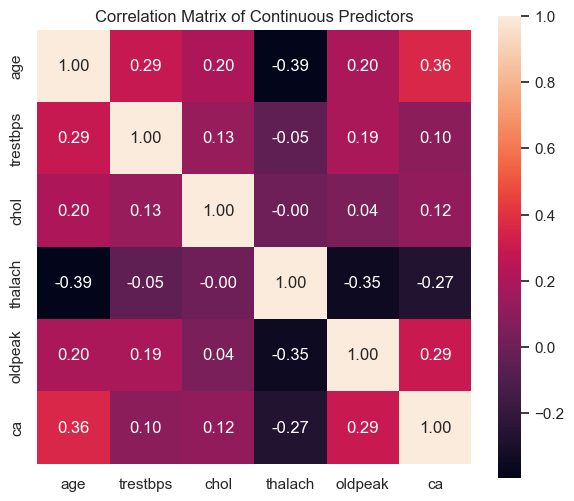

In [39]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

corr = df[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', square=True)
plt.title('Correlation Matrix of Continuous Predictors')
plt.show()

## Test vs train ROC curves

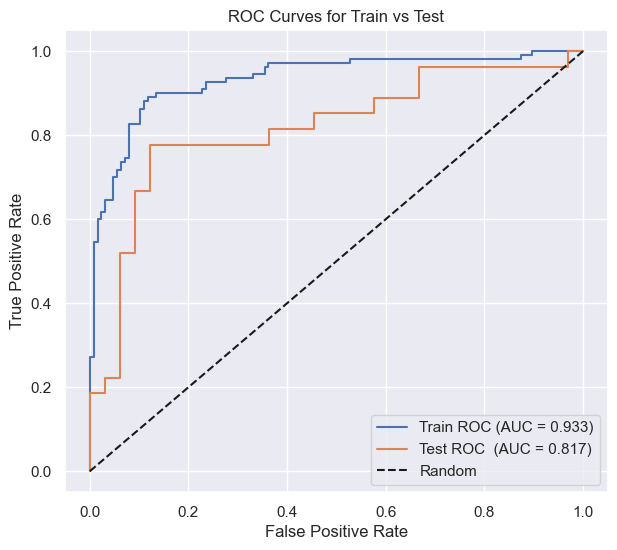

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

probs_train = complex_model.predict(df_train)
probs_test  = complex_model.predict(df_test)

fpr_train, tpr_train, _ = roc_curve(df_train['y'], probs_train)
fpr_test, tpr_test, _   = roc_curve(df_test['y'], probs_test)

auc_train = roc_auc_score(df_train['y'], probs_train)
auc_test  = roc_auc_score(df_test['y'], probs_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test,  tpr_test,  label=f'Test ROC  (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Train vs Test')
plt.legend(loc='lower right')
plt.show()

## Confusion Matrix heatmap

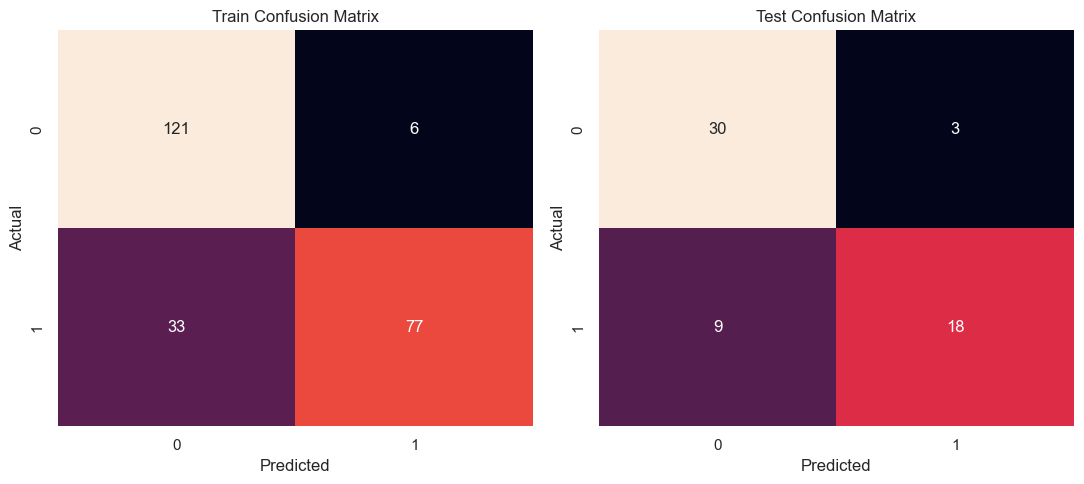

Train accuracy: 0.8354430379746836
Test accuracy:  0.8


In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score

threshold = 0.75

train_class = (probs_train >= threshold).astype(int)
test_class  = (probs_test  >= threshold).astype(int)

cm_train = confusion_matrix(df_train['y'], train_class)
cm_test  = confusion_matrix(df_test['y'],  test_class)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cbar=False, ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', cbar=False, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("Train accuracy:", accuracy_score(df_train['y'], train_class))
print("Test accuracy: ", accuracy_score(df_test['y'],  test_class))

## Model intepretation of predicted probability vs Age

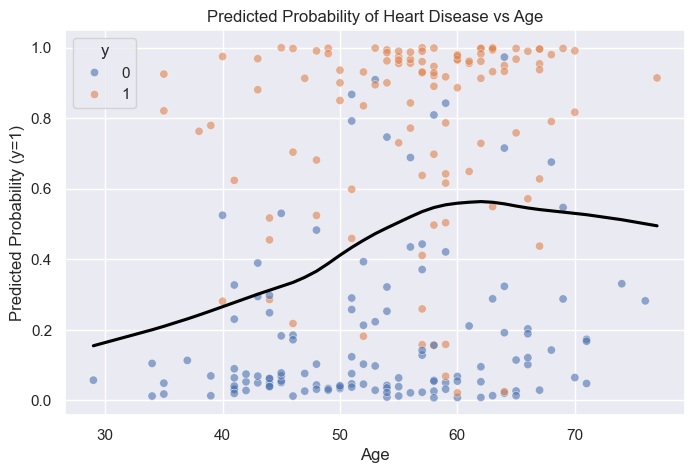

In [42]:
df_train_pred = df_train.copy()
df_train_pred['pred_prob'] = probs_train

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_train_pred, x='age', y='pred_prob', hue='y', alpha=0.6)
sns.regplot(data=df_train_pred, x='age', y='pred_prob', lowess=True, scatter=False, color='black')
plt.title('Predicted Probability of Heart Disease vs Age')
plt.xlabel('Age')
plt.ylabel('Predicted Probability (y=1)')
plt.show()

## Confusion and Odds ratio table

In [43]:
coef_table = pd.DataFrame({
    'coef': complex_model.params,
    'odds_ratio': np.exp(complex_model.params)
}).sort_values('odds_ratio', ascending=False)

coef_table

,coef,odds_ratio
Intercept,6.139108,463.639855
thal[T.reversible defect],1.941636,6.970143
ca,1.729667,5.638777
sex[T.male],1.018893,2.770127
exang[T.yes],0.708714,2.031378
oldpeak,0.169840,1.185115
thalach,-0.030608,0.969856
age,-0.040919,0.959907
slope[T.flat],-0.095252,0.909144
thal[T.normal],-0.503777,0.604244


## Roc curve visualization for training data

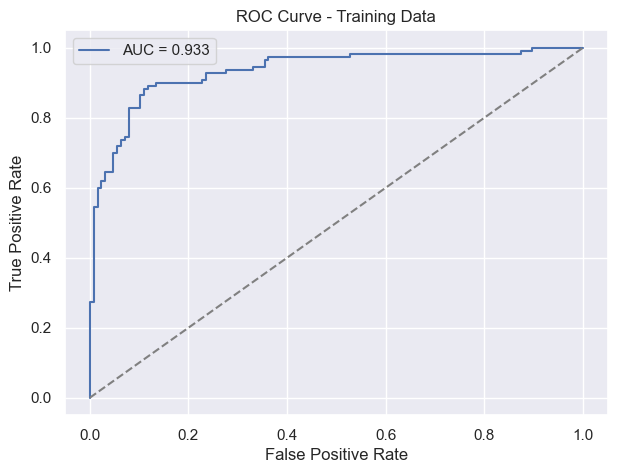

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

train_pred_prob = complex_model.predict(df_train)
fpr, tpr, thresholds = roc_curve(df_train["y"], train_pred_prob)
auc = roc_auc_score(df_train["y"], train_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Data")
plt.legend()
plt.show()

## ROC curve for test data

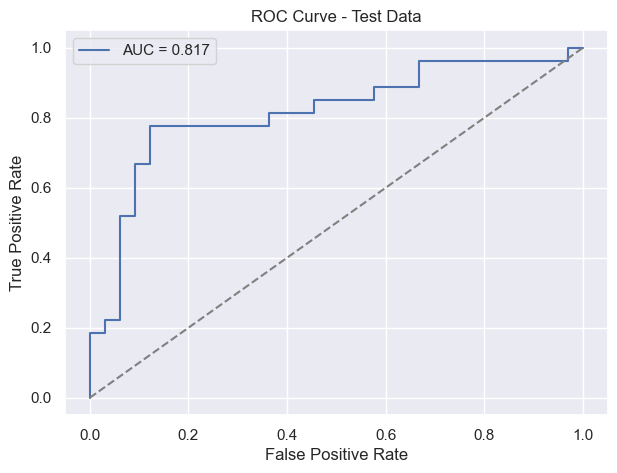

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

train_pred_prob = complex_model.predict(df_test)
fpr, tpr, thresholds = roc_curve(df_test["y"], train_pred_prob)
auc = roc_auc_score(df_test["y"], train_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.show()

## Difference between training and test data

In [46]:
train_auc = roc_auc_score(df_train["y"], complex_model.predict(df_train))
test_auc = roc_auc_score(df_test["y"], complex_model.predict(df_test))

auc_gap = train_auc - test_auc

print("Training AUC:", round(train_auc, 3))
print("Test AUC:", round(test_auc, 3))
print("AUC Gap:", round(auc_gap, 3))

if auc_gap < 0.05:
    print("\nInterpretation: The training and test AUC values are very similar.")
    print("The model generalizes well with minimal overfitting.")
elif auc_gap < 0.12:
    print("\nInterpretation: The model shows mild overfitting.")
    print("Performance decreases on unseen data, but test AUC is still strong.")
else:
    print("\nInterpretation: The model is likely overfitting.")
    print("Large AUC drop suggests the model learned patterns too specific to the training set.")

Training AUC: 0.933
Test AUC: 0.817
AUC Gap: 0.116

Interpretation: The model shows mild overfitting.
Performance decreases on unseen data, but test AUC is still strong.


## Overlayed test + training data ROC curves

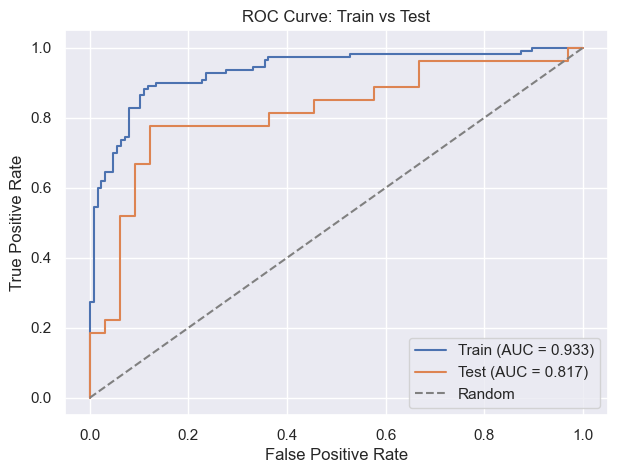

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

probs_train = complex_model.predict(df_train)
probs_test  = complex_model.predict(df_test)

fpr_train, tpr_train, _ = roc_curve(df_train["y"], probs_train)
fpr_test, tpr_test, _   = roc_curve(df_test["y"],  probs_test)

auc_train = roc_auc_score(df_train["y"], probs_train)
auc_test  = roc_auc_score(df_test["y"],  probs_test)

plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})")
plt.plot(fpr_test,  tpr_test,  label=f"Test (AUC = {auc_test:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend(loc="lower right")
plt.show()

## AUC comparison bar plot

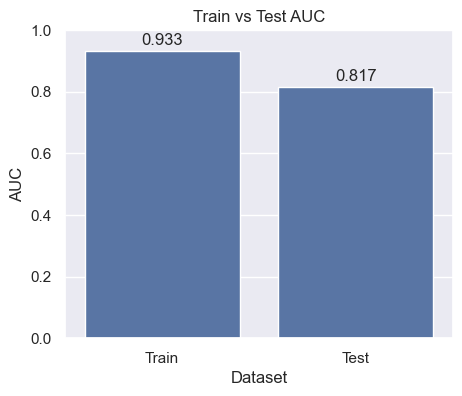

In [48]:
auc_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "AUC": [auc_train, auc_test]
})

plt.figure(figsize=(5,4))
sns.barplot(data=auc_df, x="Dataset", y="AUC")
plt.ylim(0, 1)
for i, v in enumerate(auc_df["AUC"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.title("Train vs Test AUC")
plt.ylabel("AUC")
plt.show()

## Threshold sweep to see how metrics change

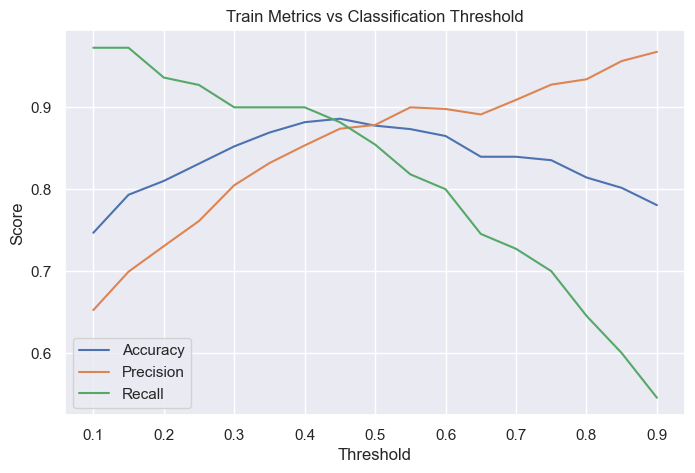

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

probs_train = complex_model.predict(df_train)
y_true = df_train["y"]

thresholds = np.linspace(0.1, 0.9, 17)  # 0.10, 0.15, ..., 0.90
acc_list = []
prec_list = []
rec_list = []

for thr in thresholds:
    y_pred = (probs_train >= thr).astype(int)
    acc_list.append(accuracy_score(y_true, y_pred))
    prec_list.append(precision_score(y_true, y_pred, zero_division=0))
    rec_list.append(recall_score(y_true, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, acc_list, label="Accuracy")
plt.plot(thresholds, prec_list, label="Precision")
plt.plot(thresholds, rec_list, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Train Metrics vs Classification Threshold")
plt.legend()
plt.show()


## Bar plot

In [50]:
probs_age_train = model_age.predict(df_train)
probs_age_test  = model_age.predict(df_test)

auc_age_train = roc_auc_score(df_train["y"], probs_age_train)
auc_age_test  = roc_auc_score(df_test["y"], probs_age_test)

# AUC for complex model
probs_complex_train = complex_model.predict(df_train)
probs_complex_test  = complex_model.predict(df_test)

auc_complex_train = roc_auc_score(df_train["y"], probs_complex_train)
auc_complex_test  = roc_auc_score(df_test["y"], probs_complex_test)

# Comparison DataFrame (THIS is the correct variable)
compare_df = pd.DataFrame({
    "Model": ["Age-only", "Age-only", "Complex", "Complex"],
    "Dataset": ["Train", "Test", "Train", "Test"],
    "AUC": [auc_age_train, auc_age_test, auc_complex_train, auc_complex_test]
})

compare_df

,Model,Dataset,AUC
0,Age-only,Train,0.616428
1,Age-only,Test,0.732884
2,Complex,Train,0.933357
3,Complex,Test,0.817059


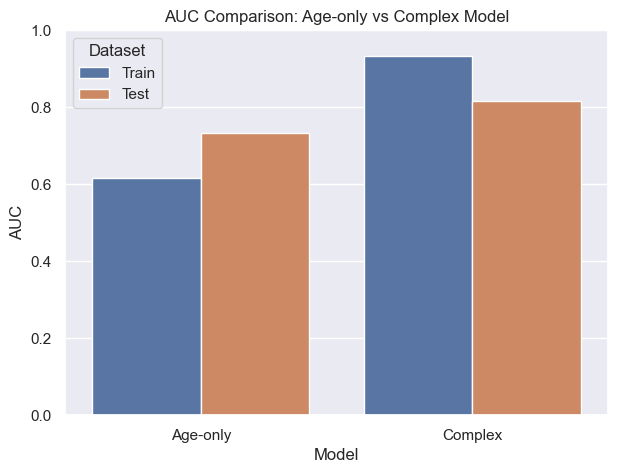

In [51]:
plt.figure(figsize=(7,5))
sns.barplot(data=compare_df, x="Model", y="AUC", hue="Dataset")
plt.ylim(0, 1)
plt.title("AUC Comparison: Age-only vs Complex Model")
plt.show()

## Compare models using stepwise variable selection

In [52]:
import statsmodels.api as sm

# 1. Separate features and target
y = df_train["y"].astype(int)

X_raw = df_train.drop(columns=["y"])

# 2. One-hot encode categoricals and make sure everything is numeric
X = pd.get_dummies(X_raw, drop_first=True).astype(float)
X

,age,trestbps,chol,thalach,oldpeak,ca,num,y_pred,sex_male,cp_atypical,cp_non-anginal,cp_typical,fbs_typical,restecg_left ventricular hypertrophy,restecg_normal,exang_yes,slope_flat,slope_upsloping,thal_normal,thal_reversible defect
22,58.0,120.0,284.0,160.0,1.8,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
262,60.0,150.0,240.0,171.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
200,50.0,110.0,254.0,159.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
246,58.0,100.0,234.0,156.0,0.1,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
100,45.0,115.0,260.0,185.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,52.0,152.0,298.0,178.0,1.2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
52,44.0,112.0,290.0,153.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
207,50.0,144.0,200.0,126.0,0.9,0.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
120,48.0,130.0,256.0,150.0,0.0,2.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [53]:
df_train.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs          object
restecg      object
thalach       int64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
y             int64
y_pred        int64
dtype: object

In [54]:
X_raw = df_train.drop(columns=["y"])
y = df_train["y"].astype(int)

# Convert all categoricals → numeric dummy variables
X = pd.get_dummies(X_raw, drop_first=True)

# Force ALL columns to float (the ultimate fix)
X = X.astype(float)

# (Optional) Confirm:
print(X.dtypes)

age                                     float64
trestbps                                float64
chol                                    float64
thalach                                 float64
oldpeak                                 float64
ca                                      float64
num                                     float64
y_pred                                  float64
sex_male                                float64
cp_atypical                             float64
cp_non-anginal                          float64
cp_typical                              float64
fbs_typical                             float64
restecg_left ventricular hypertrophy    float64
restecg_normal                          float64
exang_yes                               float64
slope_flat                              float64
slope_upsloping                         float64
thal_normal                             float64
thal_reversible defect                  float64
dtype: object


In [56]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'y'],
      dtype='object')

## AI-based Clinical Interpretation

1. Age

Physiology & Pathophysiology.
Age increases cardiovascular risk due to arterial stiffening, endothelial dysfunction, and progressive atherosclerotic plaque formation over decades. Aging also decreases vascular elasticity, increases systolic blood pressure, and contributes to left ventricular hypertrophy.

Clinical Interpretation.
Clinicians treat age as one of the strongest non-modifiable predictors of coronary artery disease (CAD). Risk accelerates after mid-life, especially above 45 in men and 55 in women.

Model Interpretation.
A logistic regression assigns a positive coefficient because increasing age corresponds to a higher likelihood of accumulated plaque burden and ischemia.

2. Maximum Heart Rate (thalach)

Physiology & Pathophysiology.
Maximum heart rate reflects chronotropic competence — the heart’s ability to increase output during exercise through sympathetic activation. Inability to reach a normal maximum heart rate (chronotropic incompetence) is associated with autonomic dysfunction, myocardial ischemia, or compromised ventricular function.

Clinical Interpretation.
In exercise testing, failure to achieve ~80–85% of age-predicted HR is considered abnormal and may indicate CAD.

Model Interpretation.
A negative coefficient is typical because higher max HR suggests better cardiovascular fitness, while lower values often indicate ischemia or reduced cardiac reserve.

3. Chest Pain Type

Physiology & Pathophysiology.
Chest pain reflects myocardial oxygen imbalance. Typical angina arises when coronary blood flow cannot meet myocardial demand during exertion due to obstructed arteries. Atypical and non-anginal pain correspond to decreasing probability of ischemia.

Clinical Interpretation.
Categorizing chest pain is central to estimating pre-test probability of CAD. Typical angina correlates most strongly with obstructive CAD.

Model Interpretation.
More ischemic pain categories receive positive coefficients, while non-anginal patterns serve as lower-risk reference groups.

4. ST Depression (oldpeak)

Physiology & Pathophysiology.
ST-segment depression during exercise or recovery indicates subendocardial ischemia, caused by inadequate coronary perfusion during increased myocardial demand.

Clinical Interpretation.
Horizontal or downsloping ST depression ≥1 mm is considered significant according to ACC/AHA exercise-testing standards. Greater depression usually indicates more severe ischemia.

Model Interpretation.
A positive coefficient is expected: more ST depression corresponds to a higher likelihood of obstructive CAD.

5. Resting ECG

Physiology & Pathophysiology.
Resting ECG abnormalities—including Q waves, ST-T changes, bundle branch blocks, or left ventricular hypertrophy—reflect structural or ischemic myocardial damage.

Clinical Interpretation.
Resting ECG is used to detect prior infarction, ischemia at rest, conduction delays, or arrhythmias. Abnormal ECG findings correlate with higher risk of CAD and adverse cardiac events.

Model Interpretation.
Abnormal ECG categories receive positive coefficients relative to a normal ECG reference.

6. Slope of Peak Exercise ST Segment (slope)

Physiology & Pathophysiology.
ST-segment slope during peak exercise reflects myocardial repolarization dynamics. Flat or downsloping ST morphology is more consistent with ischemia than upsloping patterns.

Clinical Interpretation.
Exercise-testing guidelines emphasize that ST shape, not just depth, carries significant diagnostic value. Flat or downsloping ST responses often indicate obstructive CAD.

Model Interpretation.
Flat/downsloping categories typically receive positive coefficients, while upsloping serves as the lowest-risk baseline.

7. Exercise-Induced Angina (exang)

Physiology & Pathophysiology.
Angina provoked by exercise occurs when myocardial oxygen demand exceeds coronary supply, revealing flow-limiting stenosis.

Clinical Interpretation.
Exercise-induced angina is a strong marker of true myocardial ischemia and predicts higher risk of clinically significant CAD.

Model Interpretation.
Exang = 1 receives a positive coefficient, indicating higher odds of heart disease when angina occurs.

8. CA (Number of Major Vessels Colored by Fluoroscopy)

Physiology & Pathophysiology.
This variable reflects the number of coronary arteries showing flow defects or narrowing during angiography. More diseased vessels indicate more extensive atherosclerotic burden.

Clinical Interpretation.
Multivessel disease predicts higher risk of myocardial infarction, heart failure, and death compared with single-vessel involvement. It is also central to decisions regarding revascularization.

Model Interpretation.
CA often receives one of the strongest positive coefficients, as increasing vessel involvement strongly signals presence of CAD.

9. Thalassemia-Related Defects (thal)

(In the dataset, “thal” refers to thallium perfusion defects, not genetic thalassemia.)

Physiology & Pathophysiology.
Thallium scans measure myocardial perfusion.

Fixed defects reflect scar tissue from prior infarction.

Reversible defects indicate inducible ischemia — a hallmark of obstructive CAD.

Clinical Interpretation.
Nuclear perfusion defects are used to identify ischemic territories, determine severity of CAD, guide revascularization decisions, and predict future cardiac events.

Model Interpretation.
Fixed and reversible defect categories receive positive coefficients because they directly signal myocardial ischemia or infarction.

## Literature-aware QA using HuggingFace

In [68]:
!pip install transformers torch --quiet


Python(96989) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## BioBERT QA pipeline

In [69]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline


In [70]:
model_id = "dmis-lab/biobert-base-cased-v1.1-squad"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForQuestionAnswering.from_pretrained(model_id)

qa = pipeline("question-answering", model=model, tokenizer=tokenizer)

print("BioBERT QA pipeline loaded ✅")

Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


BioBERT QA pipeline loaded ✅


In [71]:
# Short cardiology summaries for each variable you care about
contexts = {
    "trestbps": """
Resting blood pressure reflects the pressure in the arteries when the heart is beating.
Persistently elevated resting blood pressure forces the left ventricle to work harder,
causes thickening of the heart muscle, and accelerates atherosclerosis. These changes
increase the risk of coronary artery disease and cardiovascular events.
""",
    
    "chol": """
High total and LDL cholesterol promote atherosclerotic plaque formation in coronary arteries.
Cholesterol-rich lipoproteins infiltrate the arterial wall, become oxidized, and trigger
inflammation. Over time this narrows the vessel lumen, impairs blood flow to the myocardium,
and increases the risk of myocardial infarction.
""",
    
    "thalach": """
Maximum heart rate achieved during exercise (thalach) reflects the heart's ability to
increase output under stress. Lower exercise capacity or failure to reach an adequate
heart rate can signal underlying ischemic heart disease or impaired cardiac function,
and is associated with higher cardiovascular risk.
""",
    
    "oldpeak": """
ST segment depression during or after exercise indicates subendocardial ischemia.
When coronary arteries cannot deliver enough blood flow to meet the increased oxygen
demand of exercise, the resulting ischemia produces ST depression on the ECG.
Greater degrees of ST depression are associated with more severe coronary artery disease.
""",
    
    "ca": """
The number of major coronary vessels visualized with significant narrowing on angiography
reflects the anatomical extent of coronary artery disease. Multivessel involvement is
associated with higher risk of myocardial infarction, heart failure, and death compared
with single-vessel disease.
""",
    
    "thal": """
In this dataset, thallium perfusion scan results are coded as normal, fixed defect,
or reversible defect. Fixed defects usually represent scar from prior myocardial infarction,
while reversible defects indicate inducible ischemia due to flow-limiting coronary stenosis.
Abnormal thallium defects therefore signal the presence of clinically important CAD.
"""
}


In [72]:
questions = {
    "trestbps": "According to the context, why does high resting blood pressure increase heart disease risk?",
    "chol": "How does high cholesterol promote coronary artery disease?",
    "thalach": "Clinically, what does a low maximum heart rate achieved on exercise testing suggest?",
    "oldpeak": "What does ST segment depression during exercise indicate about coronary artery disease?",
    "ca": "Why does having more diseased coronary vessels increase a patient's cardiac risk?",
    "thal": "What do fixed and reversible thallium perfusion defects indicate clinically?"
}


In [73]:
results = {}

for var, context in contexts.items():
    question = questions[var]
    answer = qa(question=question, context=context)
    results[var] = answer["answer"]
    
    print(f"Variable: {var}")
    print("Q:", question)
    print("A:", answer["answer"])
    print("-" * 80)

results


Variable: trestbps
Q: According to the context, why does high resting blood pressure increase heart disease risk?
A: forces the left ventricle to work harder
--------------------------------------------------------------------------------
Variable: chol
Q: How does high cholesterol promote coronary artery disease?
A: atherosclerotic plaque formation
--------------------------------------------------------------------------------
Variable: thalach
Q: Clinically, what does a low maximum heart rate achieved on exercise testing suggest?
A: ischemic heart disease or impaired cardiac function
--------------------------------------------------------------------------------
Variable: oldpeak
Q: What does ST segment depression during exercise indicate about coronary artery disease?
A: subendocardial ischemia
--------------------------------------------------------------------------------
Variable: ca
Q: Why does having more diseased coronary vessels increase a patient's cardiac risk?
A: Multive

{'trestbps': 'forces the left ventricle to work harder',
 'chol': 'atherosclerotic plaque formation',
 'thalach': 'ischemic heart disease or impaired cardiac function',
 'oldpeak': 'subendocardial ischemia',
 'ca': 'Multivessel involvement',
 'thal': 'CAD'}

In [74]:
df.columns
df_train.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'y', 'y_pred'],
      dtype='object')

In [75]:
pip install --upgrade pip


Python(97009) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [76]:
pip install transformers torch --quiet


Python(97014) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


## Turning it into a QA ChatBot

In [77]:
import textwrap

from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

model_id = "dmis-lab/biobert-base-cased-v1.1-squad"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForQuestionAnswering.from_pretrained(model_id)

qa = pipeline("question-answering", model=model, tokenizer=tokenizer)

# if you already defined your contexts dictionary:
from contexts_for_qa import contexts  # or paste your dict here

all_context = "\n\n".join(contexts.values())

while True:
    user_q = input("\nAsk a cardiology question (or type 'quit'): ")
    if user_q.lower() in ["quit", "exit"]:
        break

    answer = qa(question=user_q, context=all_context)
    print("\nAnswer:", textwrap.fill(answer['answer'], width=80))

Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


ModuleNotFoundError: No module named 'contexts_for_qa'

In [80]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

model_id = "dmis-lab/biobert-base-cased-v1.1-squad"

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    local_files_only=True
)
model = AutoModelForQuestionAnswering.from_pretrained(
    model_id,
    local_files_only=True
)

qa = pipeline("question-answering", model=model, tokenizer=tokenizer)

print("BioBERT QA pipeline loaded ✅ (local cache)")


Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


BioBERT QA pipeline loaded ✅ (local cache)


In [ ]:
import textwrap

all_context = "\n\n".join(contexts.values())  # mash all variable explanations together

while True:
    user_q = input("\nAsk a cardiology question (or type 'quit'): ")
    if user_q.lower() in ["quit", "exit"]:
        break

    answer = qa(question=user_q, context=all_context)
    print("\nAnswer:", textwrap.fill(answer["answer"], width=80))



Answer: Multivessel involvement


In [ ]:
contexts = {
    "trestbps": """...""",
    "chol": """...""",
    "thalach": """...""",
    "oldpeak": """...""",
    "ca": """...""",
    "thal": """..."""
}


In [3]:
contexts["heart_anatomy"] = """
The human heart has four main chambers: the right atrium, right ventricle,
left atrium, and left ventricle. These four parts work together to pump
oxygen-poor blood to the lungs and oxygen-rich blood to the rest of the body.
"""


In [5]:
all_context = "\n\n".join(contexts.values())
all_context


'...\n\n...\n\n...\n\n...\n\n...\n\n...\n\n\nThe human heart has four main chambers: the right atrium, right ventricle,\nleft atrium, and left ventricle. These four parts work together to pump\noxygen-poor blood to the lungs and oxygen-rich blood to the rest of the body.\n'

In [6]:
qa(question="How many parts are in the heart?", context=all_context)

NameError: name 'qa' is not defined

In [2]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

model_id = "dmis-lab/biobert-base-cased-v1.1-squad"

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    local_files_only=True
)
model = AutoModelForQuestionAnswering.from_pretrained(
    model_id,
    local_files_only=True
)

qa = pipeline("question-answering", model=model, tokenizer=tokenizer)

print("BioBERT QA pipeline loaded ✅ (local cache)")


/Users/anikajayanth/Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


BioBERT QA pipeline loaded ✅ (local cache)


In [1]:
print("BioBERT QA pipeline loaded (local cache)")


BioBERT QA pipeline loaded (local cache)


In [4]:
# qa_bot.py
import textwrap
import pandas as pd
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

# ---------- 1. Knowledge base: contexts about each variable ----------
contexts = {
    "trestbps": """
Resting blood pressure reflects the pressure in the arteries when the heart is beating.
Persistently elevated resting blood pressure forces the left ventricle to work harder,
thickens the heart muscle, and accelerates atherosclerosis. This increases the risk of
coronary artery disease and cardiovascular events.
""",
    "chol": """
High total and LDL cholesterol promote atherosclerotic plaque formation in coronary arteries.
Cholesterol-rich lipoproteins infiltrate the arterial wall, become oxidized, and trigger
inflammation. Over time this narrows the vessel lumen and increases the risk of myocardial infarction.
""",
    "thalach": """
Maximum heart rate achieved during exercise (thalach) reflects the heart's ability to increase
output under stress. Lower exercise capacity or failure to reach an adequate heart rate can
signal underlying ischemic heart disease or impaired cardiac function.
""",
    "oldpeak": """
ST segment depression during or after exercise indicates subendocardial ischemia.
When coronary arteries cannot deliver enough blood flow to meet the increased oxygen
demand of exercise, the resulting ischemia produces ST depression on the ECG.
""",
    "ca": """
The number of major coronary vessels with significant narrowing on angiography reflects the
anatomical extent of coronary artery disease. Having more diseased vessels is associated with
higher risk of myocardial infarction, heart failure, and death.
""",
    "thal": """
In this dataset, thallium perfusion scan results are coded as normal, fixed defect, or
reversible defect. Fixed defects usually indicate prior myocardial infarction, while
reversible defects indicate inducible ischemia due to flow-limiting coronary stenosis.
""",
    "heart_anatomy": """
The human heart has four main chambers: the right atrium, right ventricle,
left atrium, and left ventricle. These four parts work together to pump
oxygen-poor blood to the lungs and oxygen-rich blood to the rest of the body.
"""
}

# ---------- 2. (Optional) Add simple dataset facts to the context ----------
try:
    df = pd.read_csv("processed_cleveland.csv")
    n_patients = len(df)
    mean_age = df["age"].astype(float).mean()
    dataset_text = f"""
In this dataset there are {n_patients} patients with suspected heart disease.
The average age in the sample is about {mean_age:.1f} years. Variables such as
resting blood pressure (trestbps), cholesterol (chol), maximum heart rate
(thalach), ST depression (oldpeak), number of diseased vessels (ca), and thallium
scan results (thal) are used to predict the presence of heart disease.
"""
except Exception:
    dataset_text = ""

all_context = "\n\n".join(contexts.values()) + "\n\n" + dataset_text

# ---------- 3. Load BioBERT QA model ----------
def load_model():
    model_id = "dmis-lab/biobert-base-cased-v1.1-squad"

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        local_files_only=True   # use cached model, no internet
    )

    model = AutoModelForQuestionAnswering.from_pretrained(
        model_id,
        local_files_only=True
    )

    qa_pipeline = pipeline(
        "question-answering",
        model=model,
        tokenizer=tokenizer
    )

    print("BioBERT QA model loaded (local cache)")
    return qa_pipeline


In [5]:
# ----- 3. Load BioBERT QA model -----
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

def load_model():
    model_id = "dmis-lab/biobert-base-cased-v1.1-squad"

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        local_files_only=True  # <- LOAD FROM CACHE
    )
    model = AutoModelForQuestionAnswering.from_pretrained(
        model_id,
        local_files_only=True
    )

    qa_pipeline = pipeline(
        "question-answering",
        model=model,
        tokenizer=tokenizer
    )

    print("BioBERT QA model loaded (local cache)")
    return qa_pipeline


In [6]:
qa = load_model()


Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


BioBERT QA model loaded (local cache)


In [13]:
qa

In [14]:
qa(question="How many parts are in the heart?", context=all_context)


{'score': 0.23423301056027412, 'start': 51, 'end': 55, 'answer': 'four'}

In [7]:
eval_set = [
    {"q": "How many chambers are in the heart?", 
     "a": "four"},
    {"q": "What does ST depression indicate?", 
     "a": "subendocardial ischemia"},
    {"q": "What is a normal resting heart rate?", 
     "a": "60 to 100 beats per minute"},
    # add ~20–50 like this
]

def normalize(text):
    import re
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.strip()

correct = 0
for item in eval_set:
    pred = qa(question=item["q"], context=all_context)["answer"]
    if normalize(pred) in normalize(item["a"]) or normalize(item["a"]) in normalize(pred):
        correct += 1

accuracy = correct / len(eval_set)
print("Accuracy:", accuracy)


Accuracy: 0.6666666666666666
